<a href="https://colab.research.google.com/github/nadeen-magdy-tawadrous/Final-Project-NTI/blob/main/FP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, recall_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

In [38]:
column_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]


In [39]:
train_df = pd.read_csv('/content/KDDTrain.csv', header=None, names=column_names)

In [40]:
train_df.head(9000)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,0,tcp,private,S0,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
8996,0,tcp,telnet,S0,0,0,0,0,0,0,...,0.07,0.08,0.00,0.00,1.00,1.00,0.00,0.00,neptune,18
8997,0,tcp,http,SF,210,2480,0,0,0,0,...,1.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
8998,0,tcp,finger,SF,8,147,0,0,0,0,...,0.00,0.02,0.00,0.00,0.62,0.00,0.00,0.00,normal,18


In [41]:
test_df = pd.read_csv('/content/KDDTest.csv', header=None, names=column_names)

In [42]:
test_df.head(200000)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.00,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.00,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.00,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.00,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.00,0.0,0.83,0.71,mscan,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22538,0,tcp,smtp,SF,794,333,0,0,0,0,...,0.72,0.06,0.01,0.01,0.01,0.0,0.00,0.00,normal,21
22539,0,tcp,http,SF,317,938,0,0,0,0,...,1.00,0.00,0.01,0.01,0.01,0.0,0.00,0.00,normal,21
22540,0,tcp,http,SF,54540,8314,0,0,0,2,...,1.00,0.00,0.00,0.00,0.00,0.0,0.07,0.07,back,15
22541,0,udp,domain_u,SF,42,42,0,0,0,0,...,0.99,0.01,0.00,0.00,0.00,0.0,0.00,0.00,normal,21


In [43]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [44]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22543 entries, 0 to 22542
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     22543 non-null  int64  
 1   protocol_type                22543 non-null  object 
 2   service                      22543 non-null  object 
 3   flag                         22543 non-null  object 
 4   src_bytes                    22543 non-null  int64  
 5   dst_bytes                    22543 non-null  int64  
 6   land                         22543 non-null  int64  
 7   wrong_fragment               22543 non-null  int64  
 8   urgent                       22543 non-null  int64  
 9   hot                          22543 non-null  int64  
 10  num_failed_logins            22543 non-null  int64  
 11  logged_in                    22543 non-null  int64  
 12  num_compromised              22543 non-null  int64  
 13  root_shell      

In [45]:
test_df .isnull() . sum()

,0
duration,0
protocol_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


In [46]:
train_df .isnull() . sum()

,0
duration,0
protocol_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


In [47]:
print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (125973, 43)
Test Shape: (22543, 43)


In [48]:
y_train = train_df['label'].astype(str).str.strip().apply(lambda x: 0 if 'normal' in x.lower() else 1)
y_test = test_df['label'].astype(str).str.strip().apply(lambda x: 0 if 'normal' in x.lower() else 1)

X_train = train_df.drop(columns=['label', 'difficulty_level'], errors='ignore')
X_test = test_df.drop(columns=['label', 'difficulty_level'], errors='ignore')

cat_cols = ['protocol_type', 'service', 'flag']
X_train_enc = pd.get_dummies(X_train, columns=cat_cols)
X_test_enc = pd.get_dummies(X_test, columns=cat_cols)
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)

imputer = SimpleImputer(strategy='constant', fill_value=0)
X_train_scaled = imputer.fit_transform(X_train_scaled)
X_test_scaled = imputer.transform(X_test_scaled)

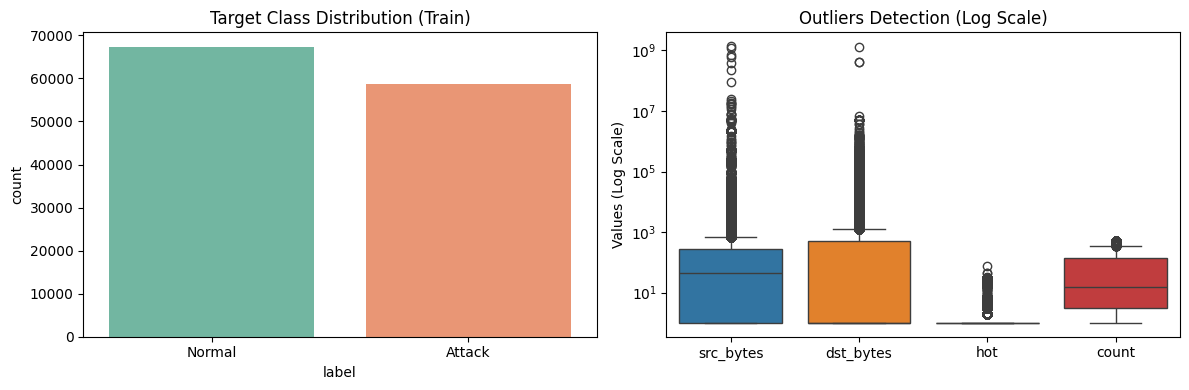

In [49]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.countplot(x=y_train, hue=y_train, palette='Set2', legend=False)
plt.title('Target Class Distribution (Train)')
plt.xticks([0, 1], ['Normal', 'Attack'])

plt.subplot(1, 2, 2)
feature_names_plot = ['src_bytes', 'dst_bytes', 'hot', 'count']
data_outliers = train_df[feature_names_plot].copy()

sns.boxplot(data=data_outliers + 1)
plt.yscale('log')
plt.title('Outliers Detection (Log Scale)')
plt.ylabel('Values (Log Scale)')

plt.tight_layout()
plt.show()

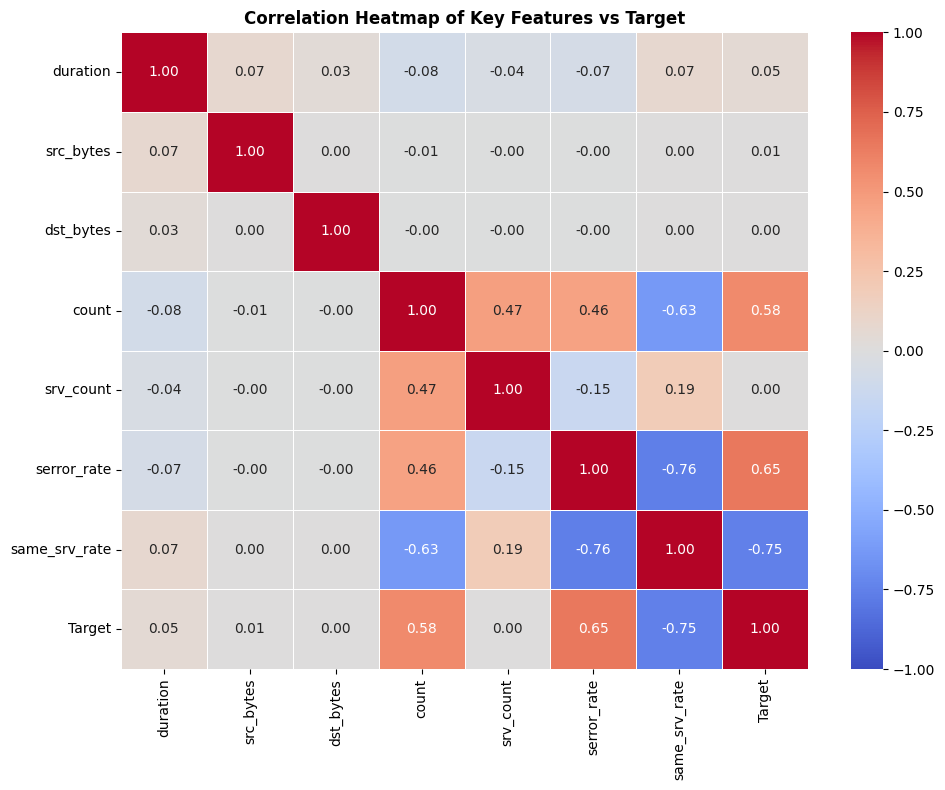

In [50]:
plt.figure(figsize=(10, 8))

selected_cols = ['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count', 'serror_rate', 'same_srv_rate']
corr_df = train_df[selected_cols].copy()
corr_df['Target'] = y_train

corr_matrix = corr_df.corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap of Key Features vs Target', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()





=== Logistic Regression Accuracy: 75.38% ===
              precision    recall  f1-score   support

      Normal       0.65      0.93      0.76      9710
      Attack       0.92      0.62      0.74     12833

    accuracy                           0.75     22543
   macro avg       0.78      0.77      0.75     22543
weighted avg       0.80      0.75      0.75     22543



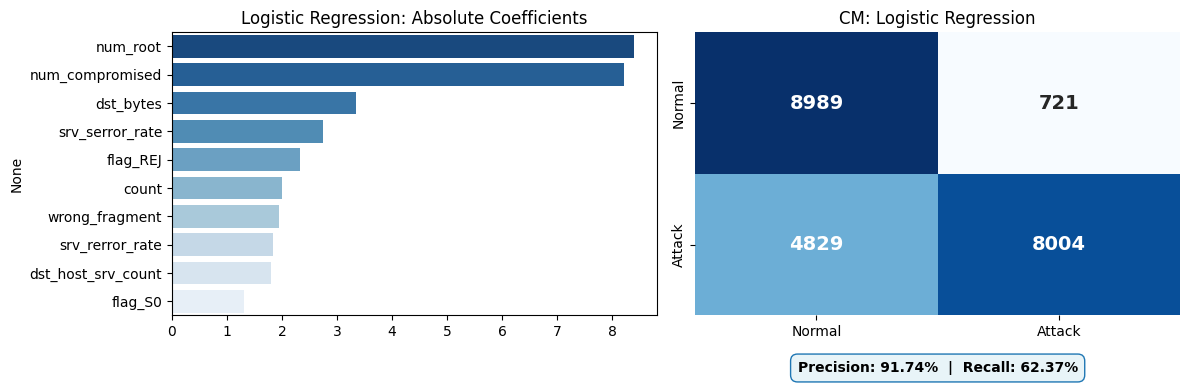

In [51]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

lr_acc = accuracy_score(y_test, lr_preds)
lr_prec = precision_score(y_test, lr_preds)
lr_rec = recall_score(y_test, lr_preds)

print(f"=== Logistic Regression Accuracy: {lr_acc*100:.2f}% ===")
print(classification_report(y_test, lr_preds, target_names=['Normal', 'Attack']))


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

lr_coefs = pd.Series(lr_model.coef_[0], index=X_train_enc.columns)
top_lr = lr_coefs.abs().sort_values(ascending=False).head(10)
sns.barplot(x=top_lr.values, y=top_lr.index, ax=axes[0], palette="Blues_r")
axes[0].set_title("Logistic Regression: Absolute Coefficients")

cm_lr = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False, annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title("CM: Logistic Regression")
axes[1].set_xticklabels(['Normal', 'Attack'])
axes[1].set_yticklabels(['Normal', 'Attack'])

stats_text = f"Precision: {lr_prec*100:.2f}%  |  Recall: {lr_rec*100:.2f}%"
axes[1].text(0.5, -0.2, stats_text, transform=axes[1].transAxes, ha="center", fontsize=10, weight='bold',
             bbox={"boxstyle": "round,pad=0.5", "facecolor": "#e8f4f8", "edgecolor": "#1f77b4"})

plt.tight_layout()
plt.show()

=== Random Forest Accuracy: 76.48% ===
              precision    recall  f1-score   support

      Normal       0.65      0.97      0.78      9710
      Attack       0.97      0.61      0.75     12833

    accuracy                           0.76     22543
   macro avg       0.81      0.79      0.76     22543
weighted avg       0.83      0.76      0.76     22543



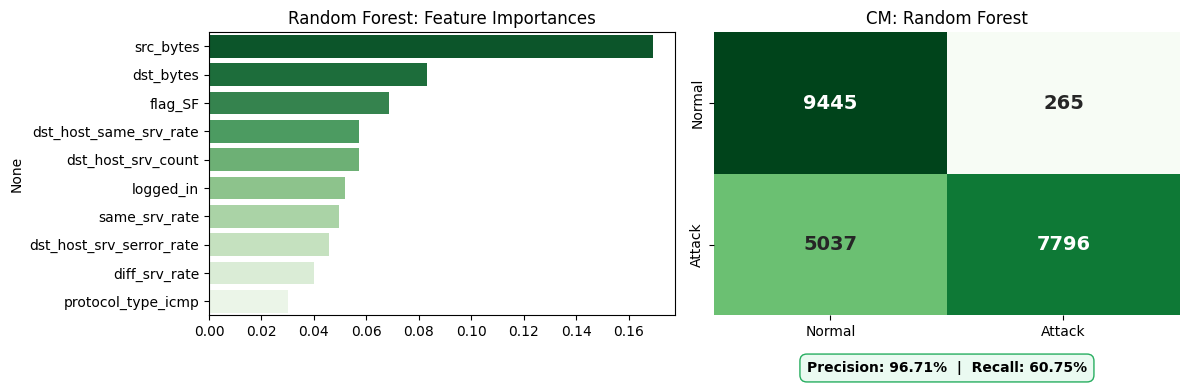

In [52]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)

rf_acc = accuracy_score(y_test, rf_preds)
rf_prec = precision_score(y_test, rf_preds)
rf_rec = recall_score(y_test, rf_preds)

print(f"=== Random Forest Accuracy: {rf_acc*100:.2f}% ===")
print(classification_report(y_test, rf_preds, target_names=['Normal', 'Attack']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

rf_importances = pd.Series(rf_model.feature_importances_, index=X_train_enc.columns)
top_rf = rf_importances.sort_values(ascending=False).head(10)
sns.barplot(x=top_rf.values, y=top_rf.index, ax=axes[0], palette="Greens_r")
axes[0].set_title("Random Forest: Feature Importances")

cm_rf = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False, annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title("CM: Random Forest")
axes[1].set_xticklabels(['Normal', 'Attack'])
axes[1].set_yticklabels(['Normal', 'Attack'])

stats_text = f"Precision: {rf_prec*100:.2f}%  |  Recall: {rf_rec*100:.2f}%"
axes[1].text(0.5, -0.2, stats_text, transform=axes[1].transAxes, ha="center", fontsize=10, weight='bold',
             bbox={"boxstyle": "round,pad=0.5", "facecolor": "#eafaf1", "edgecolor": "#27ae60"})

plt.tight_layout()
plt.show()

=== XGBoost Accuracy: 80.18% ===
              precision    recall  f1-score   support

      Normal       0.69      0.97      0.81      9710
      Attack       0.97      0.67      0.79     12833

    accuracy                           0.80     22543
   macro avg       0.83      0.82      0.80     22543
weighted avg       0.85      0.80      0.80     22543



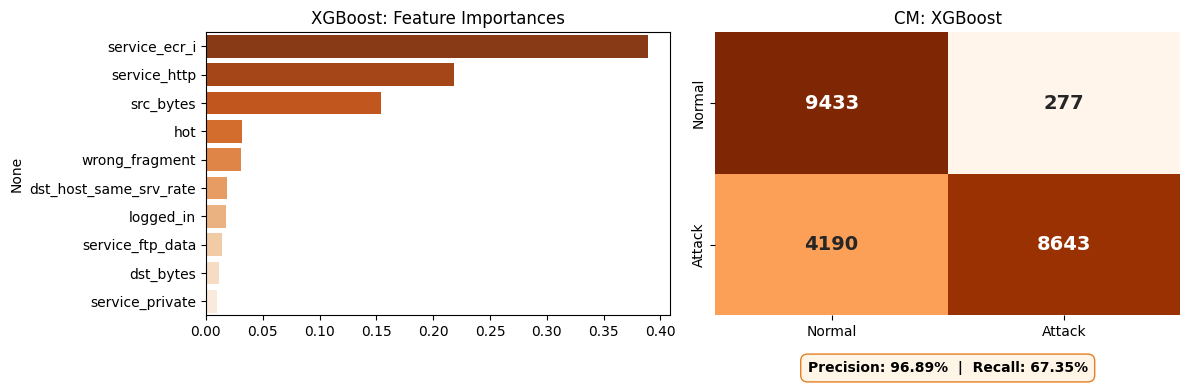

In [53]:
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_scaled, y_train)
xgb_preds = xgb_model.predict(X_test_scaled)

xgb_acc = accuracy_score(y_test, xgb_preds)
xgb_prec = precision_score(y_test, xgb_preds)
xgb_rec = recall_score(y_test, xgb_preds)

print(f"=== XGBoost Accuracy: {xgb_acc*100:.2f}% ===")
print(classification_report(y_test, xgb_preds, target_names=['Normal', 'Attack']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

xgb_importances = pd.Series(xgb_model.feature_importances_, index=X_train_enc.columns)
top_xgb = xgb_importances.sort_values(ascending=False).head(10)
sns.barplot(x=top_xgb.values, y=top_xgb.index, ax=axes[0], palette="Oranges_r")
axes[0].set_title("XGBoost: Feature Importances")

cm_xgb = confusion_matrix(y_test, xgb_preds)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar=False, annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title("CM: XGBoost")
axes[1].set_xticklabels(['Normal', 'Attack'])
axes[1].set_yticklabels(['Normal', 'Attack'])

stats_text = f"Precision: {xgb_prec*100:.2f}%  |  Recall: {xgb_rec*100:.2f}%"
axes[1].text(0.5, -0.2, stats_text, transform=axes[1].transAxes, ha="center", fontsize=10, weight='bold',
             bbox={"boxstyle": "round,pad=0.5", "facecolor": "#fef5e7", "edgecolor": "#e67e22"})

plt.tight_layout()
plt.show()

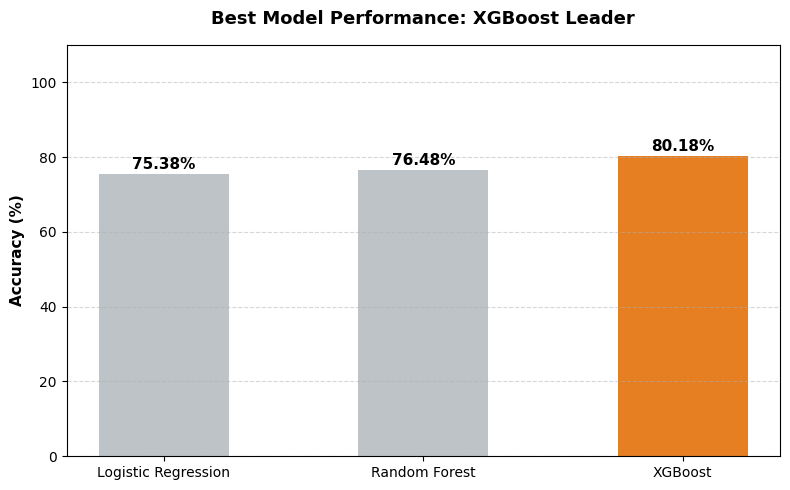

In [54]:

model_names = ['Logistic Regression', 'Random Forest', 'XGBoost']
accuracies = [lr_acc * 100, rf_acc * 100, xgb_acc * 100]

plt.figure(figsize=(8, 5))

colors = ['#bdc3c7', '#bdc3c7', '#e67e22']

bars = plt.bar(model_names, accuracies, color=colors, width=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.2f}%",
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Best Model Performance: XGBoost Leader', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [55]:
import joblib


joblib.dump(xgb_model, 'nids_xgb_model.pkl')
joblib.dump(rf_model, 'nids_rf_model.pkl')
joblib.dump(lr_model, 'nids_lr_model.pkl')

joblib.dump(scaler, 'nids_scaler.pkl')
joblib.dump(X_train_enc.columns.tolist(), 'nids_features.pkl')
joblib.dump(imputer, 'nids_imputer.pkl')

print("✅Model, Scaler, and Feature Names saved successfully with Joblib!")

✅Model, Scaler, and Feature Names saved successfully with Joblib!


In [56]:
# models = {name: joblib.load(f) for name, f in [('XGBoost', 'nids_xgb_model.pkl'),
#           ('Random Forest', 'nids_rf_model.pkl'), ('Logistic Regression', 'nids_lr_model.pkl')] if joblib.os.path.exists(f)}

# scaler = joblib.load('nids_scaler.pkl') if joblib.os.path.exists('nids_scaler.pkl') else None
# features = joblib.load('nids_features.pkl') if joblib.os.path.exists('nids_features.pkl') else [str(i) for i in range(41)]
# imputer = joblib.load('nids_imputer.pkl') if joblib.os.path.exists('nids_imputer.pkl') else None

# def predict(model_name, duration, protocol, service, flag, src_bytes, dst_bytes, count, serror_rate):
#     if model_name not in models:
#         return f"Model '{model_name}' not loaded!", {"Normal": 0.5, "Attack": 0.5}

#     row_data = {
#       'duration': duration, 'protocol_type': protocol, 'service': service, 'flag': flag,
#       'src_bytes': src_bytes, 'dst_bytes': dst_bytes, 'count': count, 'serror_rate': serror_rate
#     }
#     df_input = pd.DataFrame([row_data])
#     df_enc = pd.get_dummies(df_input, columns=['protocol_type', 'service', 'flag'])
#     df_enc = df_enc.reindex(columns=features, fill_value=0)

#     X = imputer.transform(df_enc) if imputer else df_enc.values
#     X = scaler.transform(X) if scaler else X

#     pred, probs = models[model_name].predict(X)[0], models[model_name].predict_proba(X)[0]
#     label = f" ATTACK DETECTED! ({model_name})" if pred == 1 else f" NORMAL TRAFFIC ({model_name})"
#     return label, {"Normal": float(probs[0]), "Attack": float(probs[1])}

# with gr.Blocks(title="NIDS Quick Portal") as demo:
#     gr.Markdown("#  Multi-Model NIDS Detection System")
#     with gr.Row():
#         with gr.Column():
#             model_opt = gr.Radio(['XGBoost', 'Random Forest', 'Logistic Regression'], value='XGBoost', label="Select Algorithm")
#             proto = gr.Dropdown(['tcp', 'udp', 'icmp'], value='tcp', label="Protocol")
#             serv = gr.Dropdown(['http', 'private', 'smtp', 'ftp', 'other'], value='http', label="Service")
#             flg = gr.Dropdown(['SF', 'S0', 'REJ', 'RSTO'], value='SF', label="Flag")
#             dur, src, dst, cnt = gr.Number(label="Duration", value=0), gr.Number(label="Source Bytes", value=181), gr.Number(label="Destination Bytes", value=5450), gr.Number(label="Count", value=8)
#             s_err = gr.Slider(0.0, 1.0, value=0.0, label="SYN Error Rate")
#             btn = gr.Button("Analyze Connection", variant="primary")
#         with gr.Column():
#             out_verdict = gr.Textbox(label="Verdict Result", interactive=False)
#             out_chart = gr.Label(label="Confidence Distribution")

#     btn.click(predict, inputs=[model_opt, dur, proto, serv, flg, src, dst, cnt, s_err], outputs=[out_verdict, out_chart])

# demo.launch(share=True)

In [57]:
models = {
    name: joblib.load(f)
    for name, f in [
        ("XGBoost", "nids_xgb_model.pkl"),
        ("Random Forest", "nids_rf_model.pkl"),
        ("Logistic Regression", "nids_lr_model.pkl"),
    ]
    if joblib.os.path.exists(f)
}
scaler = joblib.load("nids_scaler.pkl") if joblib.os.path.exists("nids_scaler.pkl") else None
features = joblib.load("nids_features.pkl") if joblib.os.path.exists("nids_features.pkl") else [str(i) for i in range(41)]
imputer = joblib.load("nids_imputer.pkl") if joblib.os.path.exists("nids_imputer.pkl") else None


def predict(model_name, duration, protocol, service, flag, src_bytes, dst_bytes, count, serror_rate):
    if model_name not in models:
        return f"⚠️ Model '{model_name}' not loaded!", {"Normal": 0.5, "Attack": 0.5}

    row_data = {
        "duration": duration, "protocol_type": protocol, "service": service, "flag": flag,
        "src_bytes": src_bytes, "dst_bytes": dst_bytes, "count": count, "serror_rate": serror_rate,
    }
    df_input = pd.DataFrame([row_data])
    df_enc = pd.get_dummies(df_input, columns=["protocol_type", "service", "flag"])
    df_enc = df_enc.reindex(columns=features, fill_value=0)

    X = imputer.transform(df_enc) if imputer else df_enc.values
    X = scaler.transform(X) if scaler else X

    pred = models[model_name].predict(X)[0]
    probs = models[model_name].predict_proba(X)[0]

    verdict = "🚨 ATTACK DETECTED" if pred == 1 else "✅ NORMAL TRAFFIC"
    label = f"{verdict}  —  ({model_name})"
    return label, {"Normal": float(probs[0]), "Attack": float(probs[1])}

examples = [
    ["XGBoost", 0, "tcp", "http", "SF", 232, 8153, 5, 0.0],
    ["XGBoost", 0, "tcp", "private", "S0", 0, 0, 250, 1.0],
    ["Random Forest", 0, "udp", "domain_u", "SF", 46, 75, 2, 0.0],
]

custom_red = gr.themes.Color(
    c50="#fde6e6",
    c100="#fccccc",
    c200="#f99999",
    c300="#f66666",
    c400="#f33333",
    c500="#E60000",
    c600="#cc0000",
    c700="#990000",
    c800="#660000",
    c900="#330000",
    c950="#1a0000",
)
theme = gr.themes.Soft(primary_hue=custom_red, secondary_hue="slate")

with gr.Blocks(title="NIDS - Network Intrusion Detection", theme=theme) as demo:
    gr.Markdown(
        """
        # 🛡️ Network Intrusion Detection System (NIDS)
        """
    )
    with gr.Row():
        with gr.Column(scale=1):
            model_opt = gr.Radio(
                list(models.keys()) or ["XGBoost", "Random Forest", "Logistic Regression"],
                value=list(models.keys())[0] if models else "XGBoost",
                label="Select the model",
            )
            with gr.Row():
                proto = gr.Dropdown(["tcp", "udp", "icmp"], value="tcp", label="Protocol")
                serv = gr.Dropdown(["http", "private", "smtp", "ftp", "domain_u", "other"], value="http", label="Service")
                flg = gr.Dropdown(["SF", "S0", "REJ", "RSTO"], value="SF", label="Flag")
            with gr.Row():
                dur = gr.Number(label="Duration", value=0)
                src = gr.Number(label="Source Bytes", value=181)
                dst = gr.Number(label="Destination Bytes", value=5450)
                cnt = gr.Number(label="Count", value=8)
            s_err = gr.Slider(0.1, 1.0, value=0.1, label="SYN Error Rate")
            btn = gr.Button("🔍 Analyze Connection", variant="primary")
        with gr.Column(scale=1):
            out_verdict = gr.Textbox(label="Verdict", interactive=False)
            out_chart = gr.Label(label="Confidence Distribution")

    gr.Examples(
        examples=examples,
        inputs=[model_opt, dur, proto, serv, flg, src, dst, cnt, s_err],
        outputs=[out_verdict, out_chart],
        fn=predict,
        cache_examples=False,
        label="Try ready-made examples",
    )

    btn.click(predict, inputs=[model_opt, dur, proto, serv, flg, src, dst, cnt, s_err], outputs=[out_verdict, out_chart])

    gr.Markdown(
        "<div style='text-align:center; color:gray; font-size:12px'>Built with scikit-learn, XGBoost & Gradio — NSL-KDD Dataset</div>"
    )

if __name__ == "__main__":
    demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1acf615edd4fb0ba0e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
